# AAlogoPlot.single_logo()

`AAlogoPlot.single_logo` renders a single sequence logo with optional TMD/JMD
part annotations. When `df_logo_info` is provided, a bit-score bar is added
above the logo in a second panel.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import aaanalysis as aa
import matplotlib.pyplot as plt

aa.plot_settings()

sf = aa.SequenceFeature()
df_seq = aa.load_dataset(name='DOM_GSEC', n=100)
labels = df_seq['label'].to_list()
df_parts = sf.get_df_parts(df_seq=df_seq, list_parts=['jmd_n', 'tmd', 'jmd_c'])

aal = aa.AAlogo(logo_type='probability')
df_logo = aal.get_df_logo(df_parts=df_parts, labels=labels, label_test=1)
df_logo_info = aal.get_df_logo_info(df_parts=df_parts, labels=labels, label_test=1)

aal_plot = aa.AAlogoPlot(logo_type='probability', jmd_n_len=10, jmd_c_len=10)
print(f"df_logo shape: {df_logo.shape}, positions = {len(df_logo)}")

df_logo shape: (43, 20), positions = 43


## Parameter: `df_logo`

The logo matrix returned by `AAlogo.get_df_logo`. Rows are residue positions,
columns are amino acids. `tmd_len` is derived as
`len(df_logo) - jmd_n_len - jmd_c_len` using the lengths set at initialization.

Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


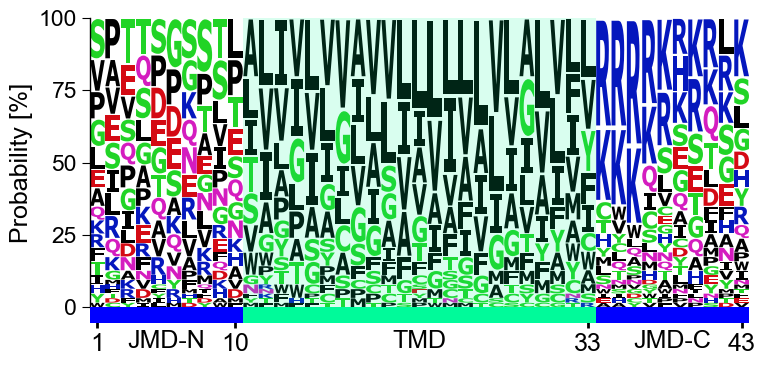

In [2]:
fig, ax = aal_plot.single_logo(df_logo=df_logo)
plt.show()

## Parameter: `df_logo_info`

When provided, a second panel is added **above** the logo showing per-position
information content as a bar chart (y-axis label: 'Bits').
The return value changes from a single `Axes` to a tuple `(ax_logo, ax_info)`.

Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


Without df_logo_info: axes type = Axes
Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


With df_logo_info:    axes type = tuple, ax_logo ylabel='Probability [%]', ax_info ylabel='Bits'


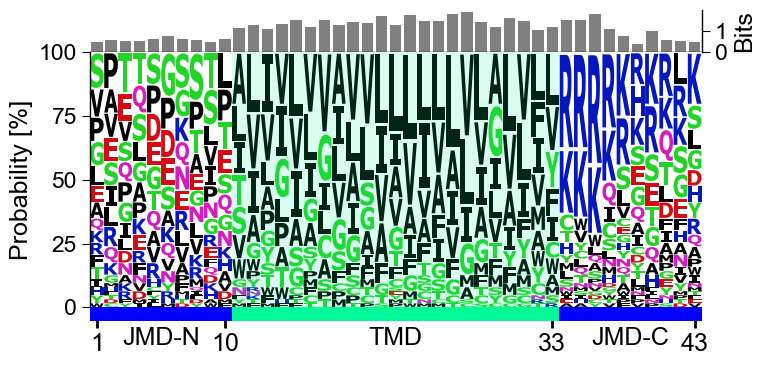

In [3]:
# Without df_logo_info: returns single Axes
fig, ax = aal_plot.single_logo(df_logo=df_logo)
print(f"Without df_logo_info: axes type = {type(ax).__name__}")
plt.close()

# With df_logo_info: returns tuple (ax_logo, ax_info)
fig, axes = aal_plot.single_logo(df_logo=df_logo, df_logo_info=df_logo_info)
ax_logo, ax_info = axes
print(f"With df_logo_info:    axes type = {type(axes).__name__}, "
      f"ax_logo ylabel='{ax_logo.get_ylabel()}', ax_info ylabel='{ax_info.get_ylabel()}'")
plt.show()

## Parameter: `info_bar_color` and `info_bar_ylim`

`info_bar_color` sets the bar color in the top panel.
`info_bar_ylim` fixes the y-axis of the top panel to `(min, max)` — useful for
comparing multiple plots on the same scale.

Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


ax_info ylim: (np.float64(0.0), np.float64(2.0))


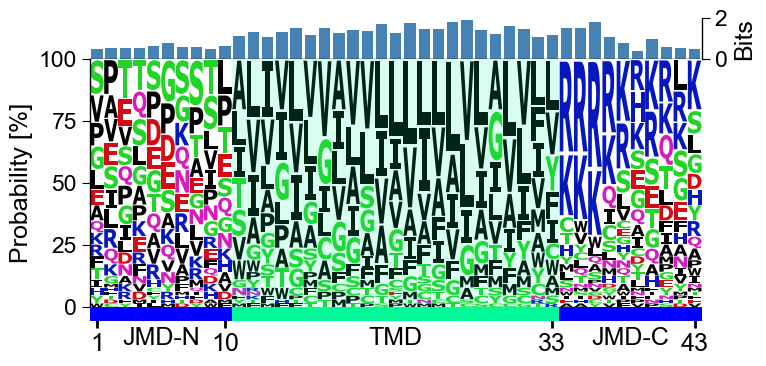

In [4]:
fig, axes = aal_plot.single_logo(
    df_logo=df_logo,
    df_logo_info=df_logo_info,
    info_bar_color='steelblue',
    info_bar_ylim=(0, 2.0),   # fix y-axis of the top panel
)
ax_logo, ax_info = axes
print(f"ax_info ylim: {ax_info.get_ylim()}")
plt.show()

## Parameter: `height_ratio`

Controls the relative height of `(info_bar_panel, logo_panel)` when
`df_logo_info` is provided. Default is `(1, 6)` — logo is 6× taller than the bar.

Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


height_ratio=(1, 6): logo/bar height ratio = 6.0


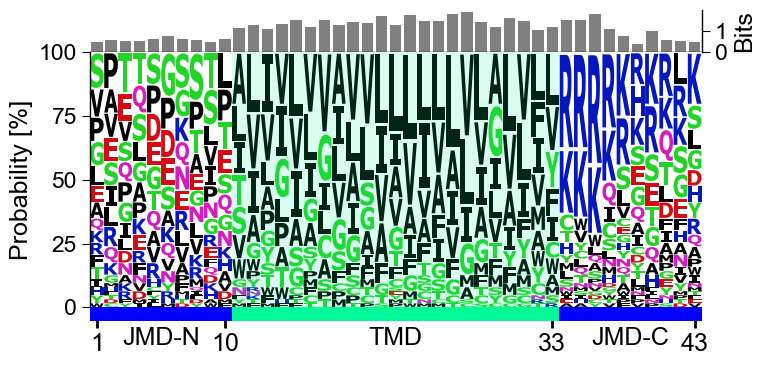

Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


height_ratio=(1, 1): logo/bar height ratio = 1.0


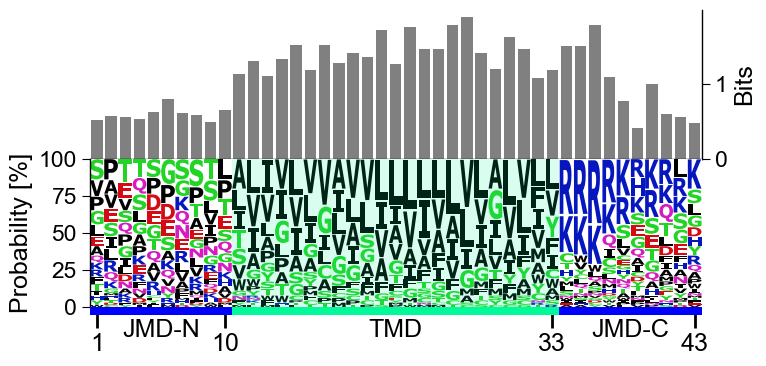

In [5]:
for ratio in [(1, 6), (1, 1)]:
    fig, axes = aal_plot.single_logo(
        df_logo=df_logo,
        df_logo_info=df_logo_info,
        height_ratio=ratio,
    )
    ax_logo, ax_info = axes
    h_logo = ax_logo.get_position().height
    h_info = ax_info.get_position().height
    print(f"height_ratio={ratio}: logo/bar height ratio = {h_logo/h_info:.1f}")
    plt.show()

## Parameter: `name_data` and `name_data_pos`

`name_data` annotates the plot with a text label.

**Routing rule**: when `df_logo_info` is provided and `name_data_pos='top'`,
the label is placed on `ax_info` (the top panel). For all other positions,
it is placed on `ax_logo`.

Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


name_data_pos='top': label placed on ax_info
Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


name_data_pos='right': label placed on ax_logo
Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


name_data_pos='left': label placed on ax_logo
Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


name_data_pos='bottom': label placed on ax_logo
Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


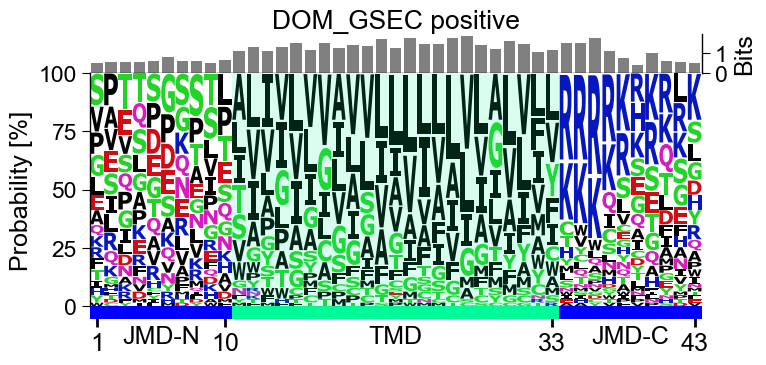

In [6]:
# With df_logo_info: 'top' goes to ax_info, other positions go to ax_logo
for pos in ['top', 'right', 'left', 'bottom']:
    fig, axes = aal_plot.single_logo(
        df_logo=df_logo,
        df_logo_info=df_logo_info,
        name_data='DOM_GSEC positive',
        name_data_pos=pos,
    )
    ax_logo, ax_info = axes
    expected_ax = 'ax_info' if pos == 'top' else 'ax_logo'
    print(f"name_data_pos='{pos}': label placed on {expected_ax}")
    plt.close()

# Show the 'top' case
fig, axes = aal_plot.single_logo(
    df_logo=df_logo, df_logo_info=df_logo_info,
    name_data='DOM_GSEC positive', name_data_pos='top',
)
plt.show()

## Parameter: `logo_type` (set at initialization)

`logo_type` at init controls the **y-axis label only**. For `'probability'`,
the backend also scales values ×100 and fixes yticks to `[0, 25, 50, 75, 100]`.
The input `df_logo` is **not mutated** — scaling is applied to an internal copy.

In [7]:
max_before = df_logo.values.max()

for logo_type in ['probability', 'counts', 'weight', 'information']:
    df_logo_t = aa.AAlogo(logo_type=logo_type).get_df_logo(
        df_parts=df_parts, labels=labels, label_test=1)
    plot = aa.AAlogoPlot(logo_type=logo_type, jmd_n_len=10, jmd_c_len=10)
    fig, ax = plot.single_logo(df_logo=df_logo_t)
    print(f"logo_type='{logo_type}': ylabel='{ax.get_ylabel()}'")
    plt.close()

# Confirm df_logo not mutated by any plot call
assert df_logo.values.max() == max_before, "df_logo was mutated!"
print(f"df_logo.max() unchanged after all plot calls: {max_before:.4f}")

Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


logo_type='probability': ylabel='Probability [%]'
Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


logo_type='counts': ylabel='Counts'
Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


logo_type='weight': ylabel='Weight'
Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


logo_type='information': ylabel='Bits'
df_logo.max() unchanged after all plot calls: 0.4444


## Parameter: `jmd_n_len` and `jmd_c_len` (set at initialization)

These derive `tmd_len = len(df_logo) - jmd_n_len - jmd_c_len`, which sets the
extent of the TMD region in the part bar, x-tick coloring, and highlight.
Here `df_logo` has 40 positions (10 + 20 + 10).

Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


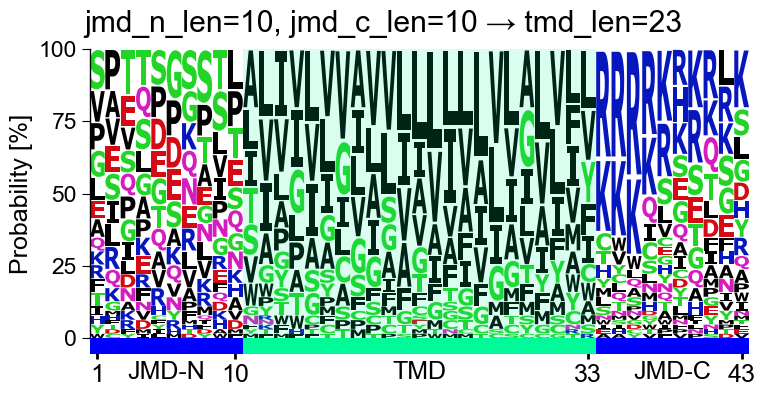

Plotting single logo (TMD length=33, JMD-N=5, JMD-C=5)


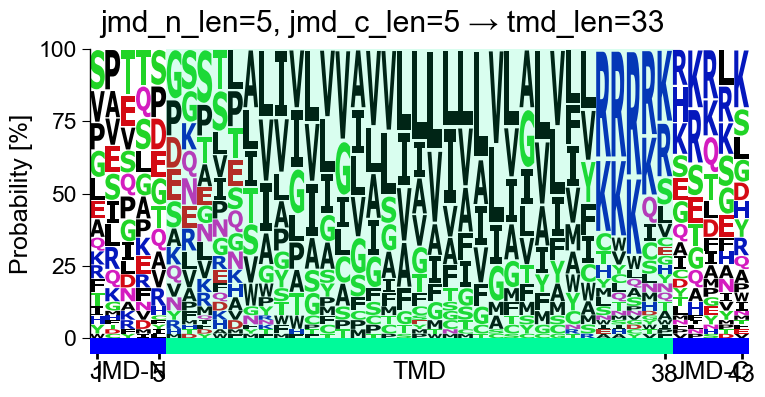

Plotting single logo (TMD length=43, JMD-N=0, JMD-C=0)


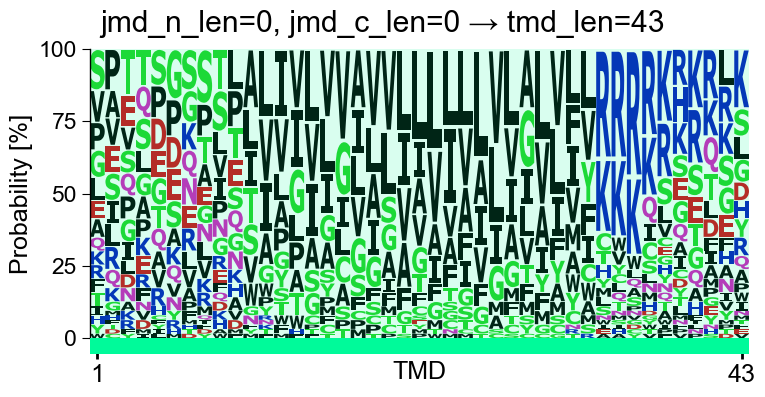

In [8]:
# Same df_logo, different jmd lengths -> different TMD region highlighted
for jmd_n, jmd_c in [(10, 10), (5, 5), (0, 0)]:
    plot = aa.AAlogoPlot(logo_type='probability', jmd_n_len=jmd_n, jmd_c_len=jmd_c)
    tmd_len = len(df_logo) - jmd_n - jmd_c
    fig, ax = plot.single_logo(df_logo=df_logo)
    fig.suptitle(f"jmd_n_len={jmd_n}, jmd_c_len={jmd_c} → tmd_len={tmd_len}", y=1.01)
    plt.show()

## Parameter: `tmd_color` and `jmd_color`

Set the color of the part bar, x-tick marks, and TMD highlight rectangle.

Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


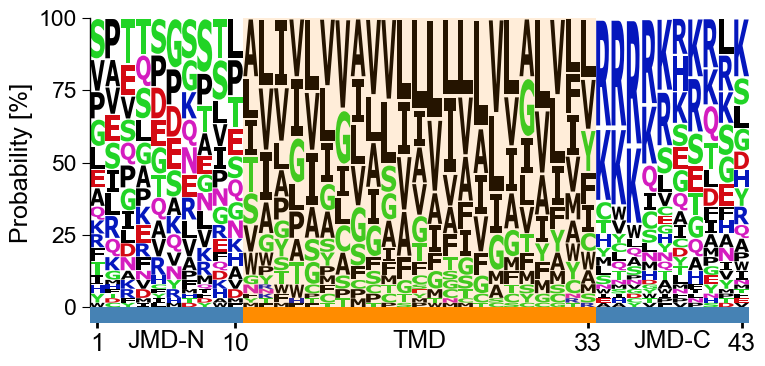

In [9]:
fig, ax = aal_plot.single_logo(
    df_logo=df_logo,
    tmd_color='darkorange',
    jmd_color='steelblue',
)
plt.show()

## Parameter: `highlight_tmd_area` and `highlight_alpha`

`highlight_tmd_area=True` (default) draws a shaded rectangle over the TMD region.
`highlight_alpha` sets its opacity.

Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


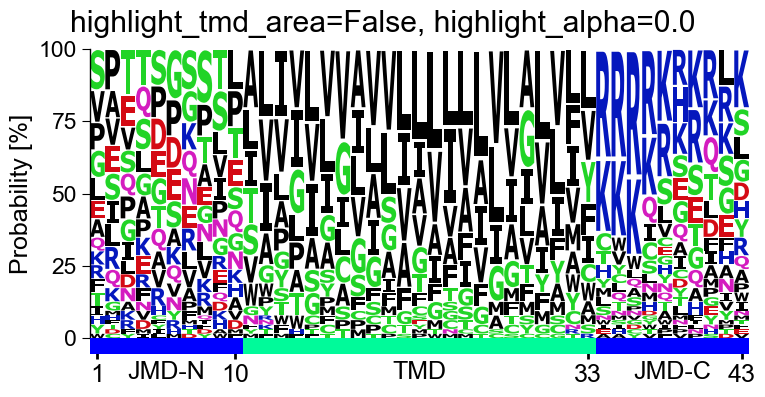

Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


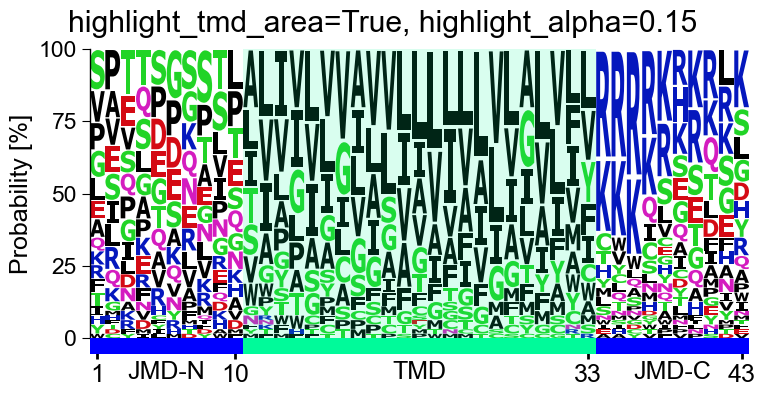

Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


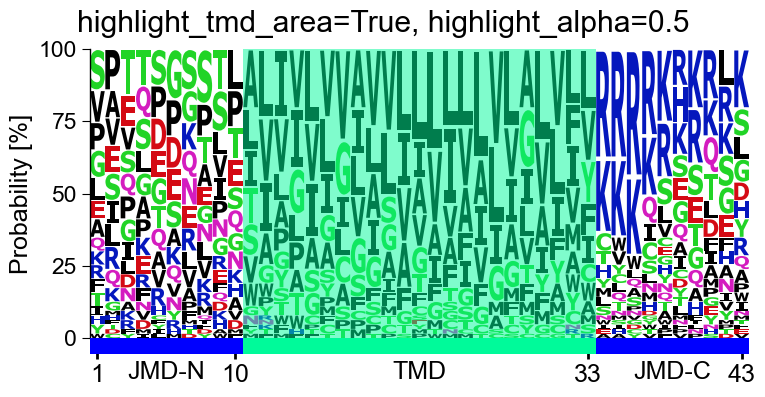

In [10]:
for alpha in [0.0, 0.15, 0.5]:
    fig, ax = aal_plot.single_logo(
        df_logo=df_logo,
        highlight_tmd_area=alpha > 0,
        highlight_alpha=alpha if alpha > 0 else 0.15,
    )
    fig.suptitle(f"highlight_tmd_area={alpha > 0}, highlight_alpha={alpha}", y=1.01)
    plt.show()

## Parameter: `start`

Shifts the x-tick **label** numbers — the first position of JMD-N gets this number.
Does not move the highlight or part bar.

In [11]:
for start in [1, 10]:
    fig, ax = aal_plot.single_logo(df_logo=df_logo, start=start)
    xtick_labels = [t.get_text() for t in ax.get_xticklabels() if t.get_text()]
    print(f"start={start}: first x-tick label = '{xtick_labels[0]}'")
    plt.close()

Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


start=1: first x-tick label = '1'
Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


start=10: first x-tick label = '10'


## Parameter: `weight_tmd_jmd` and `fontsize_tmd_jmd`

Control the font weight and size of the 'JMD-N', 'TMD', 'JMD-C' text labels
drawn below the x-axis.

Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


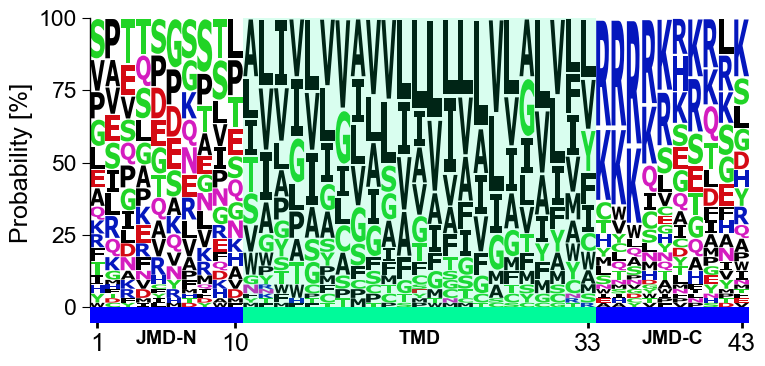

In [12]:
fig, ax = aal_plot.single_logo(
    df_logo=df_logo,
    weight_tmd_jmd='bold',
    fontsize_tmd_jmd=14,
)
plt.show()

## Parameter: `target_p1_site`

When set, **replaces** the entire TMD/JMD x-axis with P-site notation
(P2, P1, P1', P2', ...). The value is the 0-based position index of the P1 site.
All of `start`, `fontsize_tmd_jmd`, `weight_tmd_jmd`, `xtick_width`, `xtick_length`
are ignored when `target_p1_site` is set.

Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


x-tick labels: ['P10', 'P9', 'P8', 'P7', 'P6', 'P5'] ...


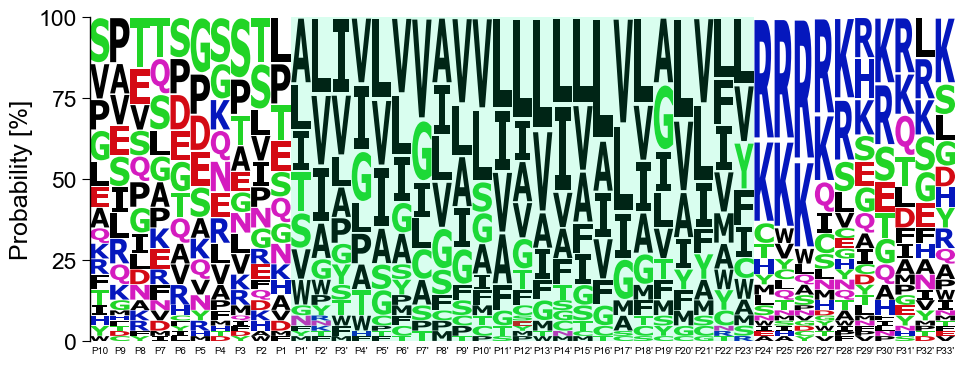

In [13]:
# P1 at position index 10 (JMD-N/TMD boundary in a 10+20+10 layout)
fig, ax = aal_plot.single_logo(df_logo=df_logo, target_p1_site=10, figsize=(10,4), xtick_size=7)
xtick_labels = [t.get_text() for t in ax.get_xticklabels()]
print(f"x-tick labels: {xtick_labels[:6]} ...")
plt.show()

## Parameter: `figsize`

Sets the `(width, height)` of the whole figure in inches.
When `df_logo_info` is provided, both panels share this total height,
split by `height_ratio`.

In [14]:
for figsize in [(8, 3), (14, 5)]:
    fig, ax = aal_plot.single_logo(df_logo=df_logo, figsize=figsize)
    actual = tuple(round(x, 1) for x in fig.get_size_inches())
    print(f"figsize={figsize}: actual fig size = {actual}")
    plt.close()

Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


figsize=(8, 3): actual fig size = (np.float64(8.0), np.float64(3.0))
Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


figsize=(14, 5): actual fig size = (np.float64(14.0), np.float64(5.0))


## Parameter: `logo_color_scheme` and `logo_stack_order`

`logo_color_scheme` is passed directly to `logomaker.Logo`.
`logo_stack_order` controls letter stacking: `'big_on_top'` (default),
`'small_on_top'`, or `'fixed'`.

Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


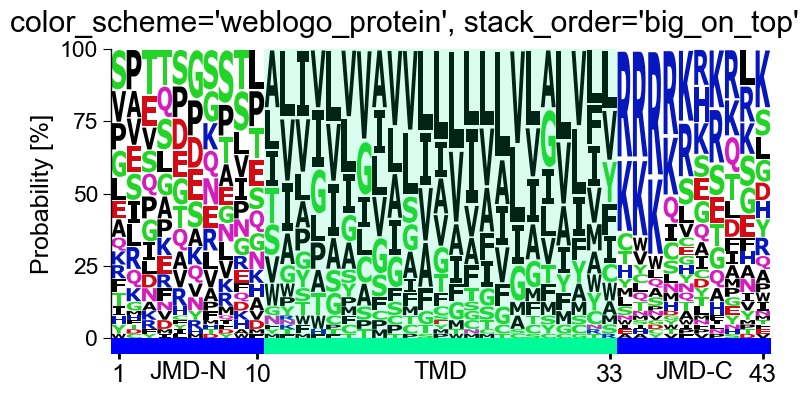

Plotting single logo (TMD length=23, JMD-N=10, JMD-C=10)


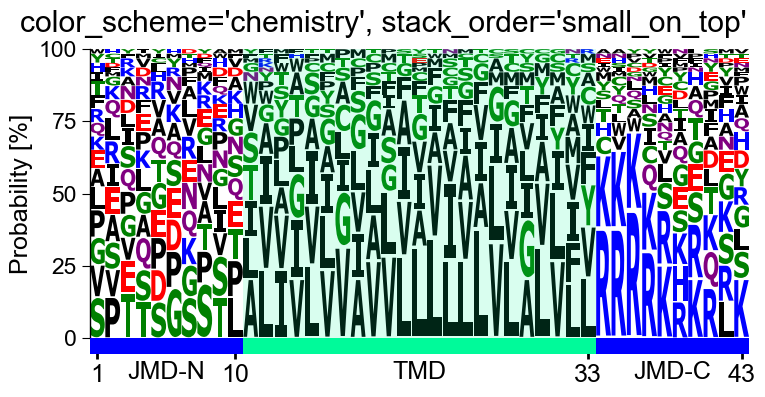

In [15]:
for scheme, order in [('weblogo_protein', 'big_on_top'), ('chemistry', 'small_on_top')]:
    fig, ax = aal_plot.single_logo(
        df_logo=df_logo,
        logo_color_scheme=scheme,
        logo_stack_order=order,
    )
    fig.suptitle(f"color_scheme='{scheme}', stack_order='{order}'", y=1.01)
    plt.show()